# Torch Batteries Example: USPS and SEMEION Named Datasets

This notebook trains one digit classifier across two [Torchvision USPS](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.USPS.html) and [SEMEION](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.SEMEION.html) datasets. It demonstrates named training, validation, testing, and prediction datasets, interleaved batches, and aggregate versus per-dataset metrics.

[DataPack guide](https://michalszc.github.io/torch-batteries/guides/data-pack/) · [Training guide](https://michalszc.github.io/torch-batteries/guides/training/)

## 0. Prerequisites

Use Python 3.12 or newer. The installation cell includes Torchvision. The first data preparation downloads USPS and SEMEION into `./data`; later runs use the cached files. USPS supplies a train and test split. SEMEION is split with fixed, stratified indices so that its training, validation, and test examples do not overlap.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup

Import the public DataPack and training APIs and report the version used for the saved results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch_batteries
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Subset
from torchvision.datasets import SEMEION, USPS
from torchvision.transforms import ToTensor

from torch_batteries import (
    BatchScheduleConfig,
    Battery,
    DataContext,
    DataLoaderConfig,
    DataPack,
    DatasetBundle,
    Event,
    EventContext,
    StepOutput,
    charge,
)

SEED = 17
torch.manual_seed(SEED)
print(f"torch-batteries version: {torch_batteries.__version__}")
print(f"PyTorch version: {torch.__version__}")

torch-batteries version: 1.0.0
PyTorch version: 2.10.0


## 2. Prepare named datasets with DataPack

`PREPARE_DATA` downloads datasets and creates fixed splits. `SETUP_DATA` returns the same names in each workflow phase. The single `batch_schedule` setting applies seeded interleave to training and validation: a loader is drawn in proportion to its remaining batch count. Both phases exhaust both loaders. `CONFIGURE_DATALOADER` sets batch sizes by phase. The names appear in step event contexts and in dataset-specific result keys only because more than one dataset is present.

In [2]:
class DigitDataPack(DataPack):
    seed = SEED

    def __init__(self, root=Path("./data")):
        self.root = Path(root)
        self.datasets = {}

    @charge(Event.PREPARE_DATA)
    def prepare(self, context: DataContext):
        transform = ToTensor()
        usps_train = USPS(self.root, train=True, transform=transform, download=True)
        usps_test = USPS(self.root, train=False, transform=transform, download=True)
        semeion = SEMEION(self.root, transform=transform, download=True)

        # Bound this example's runtime while retaining stratification.
        usps_pool, _ = train_test_split(
            np.arange(len(usps_train)), train_size=1200,
            random_state=context["seed"], stratify=usps_train.targets,
        )
        usps_fit, usps_val = train_test_split(
            usps_pool, test_size=0.2, random_state=context["seed"],
            stratify=np.asarray(usps_train.targets)[usps_pool],
        )
        usps_test_indices, _ = train_test_split(
            np.arange(len(usps_test)), train_size=300,
            random_state=context["seed"], stratify=usps_test.targets,
        )
        sem_fit, sem_holdout = train_test_split(
            np.arange(len(semeion)), test_size=0.3,
            random_state=context["seed"], stratify=semeion.labels,
        )
        sem_val, sem_test = train_test_split(
            sem_holdout, test_size=0.5, random_state=context["seed"],
            stratify=np.asarray(semeion.labels)[sem_holdout],
        )
        self.datasets = {
            "train": {"usps": Subset(usps_train, usps_fit), "semeion": Subset(semeion, sem_fit)},
            "validation": {"usps": Subset(usps_train, usps_val), "semeion": Subset(semeion, sem_val)},
            "test": {"usps": Subset(usps_test, usps_test_indices), "semeion": Subset(semeion, sem_test)},
        }

    @charge(Event.SETUP_DATA)
    def setup(self, context: DataContext):
        stage = context["stage"]
        if stage == "fit":
            return DatasetBundle(
                train=self.datasets["train"], validation=self.datasets["validation"],
                batch_schedule=BatchScheduleConfig(mode="interleave", seed=self.seed),
            )
        if stage == "test":
            return DatasetBundle(test=self.datasets["test"])
        return DatasetBundle(predict=self.datasets["test"])

    @charge(Event.CONFIGURE_DATALOADER)
    def configure(self, context: DataContext):
        return DataLoaderConfig(batch_size=64 if context["phase"] == "train" else 128)


data_pack = DigitDataPack()
with data_pack.resolve("fit") as resolved:
    for phase in ("train", "validation"):
        print(phase, {name: len(dataset) for name, dataset in resolved.datasets.datasets_for_phase(phase).items()})

train {'usps': 960, 'semeion': 1115}
validation {'usps': 240, 'semeion': 239}


## 3. Define the model and accuracy metric

The same model handles both sources because both contain 16×16 grayscale images and labels 0–9. A `StepOutput` supplies predictions and targets to Battery's automatic metric calculation.

In [3]:
from torch_batteries.callbacks import EarlyStopping


class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(nn.Flatten(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 10))

    def forward(self, images):
        return self.network(images)

    def _step(self, context):
        images, targets = context["batch"]
        logits = self(images)
        return StepOutput(loss=F.cross_entropy(logits, targets), predictions=logits, targets=targets)

    @charge(Event.TRAIN_STEP)
    def train_step(self, context: EventContext):
        return self._step(context)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        return self._step(context)

    @charge(Event.TEST_STEP)
    def test_step(self, context: EventContext):
        return self._step(context)

    @charge(Event.PREDICT_STEP)
    def predict_step(self, context: EventContext):
        images, _ = context["batch"]
        return self(images).argmax(dim=1)


def accuracy(predictions, targets):
    return (predictions.argmax(dim=1) == targets).float().mean()


model = DigitClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopping = EarlyStopping(
    phase="validation", metric="semeion:accuracy", mode="max",
    patience=4, restore_best_weights=True,
)
battery = Battery(
    model, optimizer=optimizer, metrics={"accuracy": accuracy},
    callbacks=[early_stopping], data_pack=data_pack, device="cpu",
)

## 4. Train and validate

`EarlyStopping` watches `semeion:accuracy`, demonstrating an exact named callback metric. Training runs for at most 20 epochs and stops after four validation checks without improvement, restoring the best model weights. The plain `accuracy` key is weighted over all samples; `usps:accuracy` and `semeion:accuracy` keep each source visible. The same convention applies to named loss keys. The result includes cumulative epoch and optimizer-step counts and the stop reason.

In [4]:
history = battery.fit(epochs=20, verbose=1)
print(f"Epochs: {history['epochs_completed']}; optimizer steps: {history['optimizer_steps']}")
print(f"Stopped early: {history['stopped_early']}; reason: {history['stop_reason']}")
for key, values in history["val_metrics"].items():
    print(f"Validation {key}: {values[-1]:.3f}")
print(f"Weighted validation loss: {history['val_loss'][-1]:.3f}")

Epoch 18/20 [Validation]: 100%|██████████| 4/4 [00:00<00:00, 348.00it/s, Loss=0.3896, Accuracy=0.8873, semeion:loss=0.4172, semeion:accuracy=0.8745, usps:loss=0.3621, usps:accuracy=0.9000]


Epochs: 18; optimizer steps: 594
Stopped early: True; reason: Early stopping: validation metric 'semeion:accuracy' did not improve for 4 checks (best=0.8995815847209307, latest=0.8744769921861433)
Validation accuracy: 0.887
Validation usps:loss: 0.362
Validation usps:accuracy: 0.900
Validation semeion:loss: 0.417
Validation semeion:accuracy: 0.874
Weighted validation loss: 0.390


## 5. Test both datasets

`test()` returns one aggregate result. The weighted loss is `test_loss`; `test_metrics` contains the aggregate accuracy and the named dataset metrics and losses. Selecting `dataset="usps"` runs just that source and yields only ordinary metric names.

In [5]:
test_result = battery.test(verbose=1)
print(f"Weighted test loss: {test_result['test_loss']:.3f}")
for name, value in test_result["test_metrics"].items():
    print(f"{name}: {value:.3f}")
usps_only = battery.test(dataset="usps", verbose=0)
print(f"Selected USPS accuracy: {usps_only['test_metrics']['accuracy']:.3f}")

Epoch 1/1 [Test]: 100%|██████████| 5/5 [00:00<00:00, 395.70it/s, Loss=0.3824, Accuracy=0.8942, usps:loss=0.4946, usps:accuracy=0.8767, semeion:loss=0.2416, semeion:accuracy=0.9163]


Weighted test loss: 0.382
accuracy: 0.894
usps:loss: 0.495
usps:accuracy: 0.877
semeion:loss: 0.242
semeion:accuracy: 0.916
Selected USPS accuracy: 0.877


## 6. Predict by dataset

With multiple prediction datasets, one `PredictResult` holds a mapping under `predictions`. Selecting one dataset returns the ordinary single-dataset prediction tensor.

In [6]:
prediction_result = battery.predict(verbose=1, move_to_cpu=True, concatenate=True)
for name, predictions in prediction_result["predictions"].items():
    print(f"{name}: {len(predictions)} predicted digits")
selected = battery.predict(dataset="semeion", verbose=0, move_to_cpu=True, concatenate=True)
print("Selected SEMEION predictions:", selected["predictions"][:12].tolist())

Epoch 1/1 [Predict]: 100%|██████████| 5/5 [00:00<00:00, 500.17it/s]


usps: 300 predicted digits
semeion: 239 predicted digits
Selected SEMEION predictions: [4, 9, 1, 8, 2, 3, 0, 1, 4, 0, 1, 1]


## 7. Inspect digits and predictions from both sources

Each row shows test images from one dataset. The title compares its true label with the model prediction returned by the named prediction workflow.

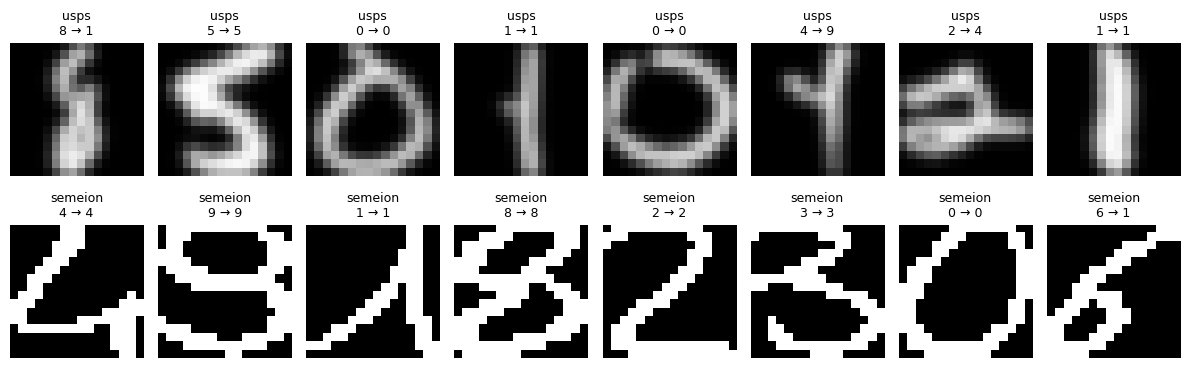

In [7]:
figure, axes = plt.subplots(2, 8, figsize=(12, 4))
for row, name in enumerate(("usps", "semeion")):
    dataset = data_pack.datasets["test"][name]
    predicted = prediction_result["predictions"][name]
    for column in range(8):
        image, true_label = dataset[column]
        axis = axes[row, column]
        axis.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"{name}\n{true_label} → {int(predicted[column])}", fontsize=9)
        axis.axis("off")
figure.tight_layout()
plt.show()

## 8. Compare source-level validation accuracy

The two named curves reveal source differences that the weighted aggregate alone can hide.

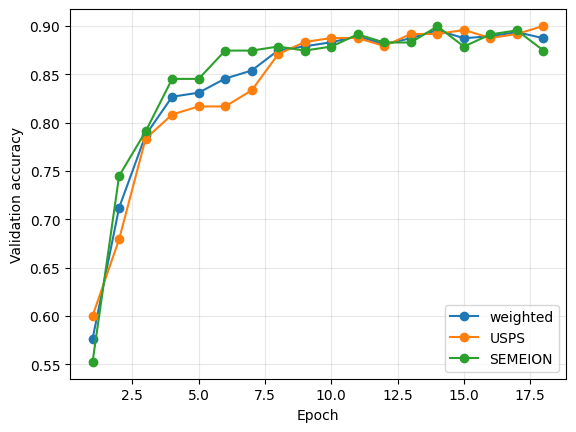

In [8]:
epochs = np.arange(1, history["epochs_completed"] + 1)
plt.plot(epochs, history["val_metrics"]["accuracy"], marker="o", label="weighted")
plt.plot(epochs, history["val_metrics"]["usps:accuracy"], marker="o", label="USPS")
plt.plot(epochs, history["val_metrics"]["semeion:accuracy"], marker="o", label="SEMEION")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()